In [3]:
import glob, os, sys, json, jax, jax_obc2, jax_model, optax, scipy
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np
import jax_amber2 as jaa
import jax.numpy as jnp
import numpy.random as npr
from flax import linen as nn 
from flax.training import train_state 
import mdtraj as md
import MDAnalysis as mda
import matplotlib as mpl
import matplotlib.pyplot as plt
from decimal import Decimal

2023-08-08 19:43:09.289553: E external/org_tensorflow/tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:267] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [7]:
#Get the Potential Function
fname_prmtop = 'Simulation/ala_deca_peptide.prmtop'
def get_amber_gas_energy_functions(fname_prmtop):
    prm_raw_data = jaa.amber_prmtop_load(fname_prmtop)
    ener_bonded_fn, ener_bond_fn = jaa.ener_bonded(prm_raw_data)
    
    chgs = jaa.prm_get_charges(prm_raw_data)
    atom_types = jaa.prm_get_atom_types(prm_raw_data)
    
    sigma, epsilon = jaa.prm_get_nonbond_terms(prm_raw_data)
    
    nonbond_pairs = jaa.prm_get_nonbond_pairs(prm_raw_data)
    ener_nbond_fn = jaa.ener_nonbonded_pair(atom_types, nonbond_pairs, sigma, epsilon, chgs)
    
    nbonds14 = jaa.prm_get_nonbond14_info(prm_raw_data)
    ener_nbond14_fn = jaa.ener_nonbonded14(atom_types, nbonds14, sigma, epsilon, chgs)
    
    ener_bonded_fn = jax.jit(ener_bonded_fn)
    ener_bond_fn = jax.jit(ener_bond_fn)
    ener_nbond_fn = jax.jit(ener_nbond_fn)
    ener_nbond14_fn = jax.jit(ener_nbond14_fn)
    #vmax0 = jnp.float32(100.0)
    @jax.vmap
    def compute_fun(R):
        """
        R (natom * 3)
        """
        #print(R.shape)
        R = R.reshape(-1,3)
        en_bonded = ener_bonded_fn(R)
        en_lj, en_chg = ener_nbond_fn(R)
        en_lj14, en_chg14 = ener_nbond14_fn(R)
        
        return en_bonded + en_lj + en_chg + en_lj14 + en_chg14

    return compute_fun, ener_bonded_fn, ener_nbond_fn, ener_nbond14_fn

gas_fun, _, _, _ = get_amber_gas_energy_functions(fname_prmtop)

In [8]:
def write_traj(fname, traj_xyz): #(n conf, n_atoms*3) OR (n conf, n_atoms, 3)
        if traj_xyz.shape[-1] != 3:
            traj_xyz = traj_xyz.reshape(traj_xyz.shape[0], -1, 3)
        
        with md.formats.DCDTrajectoryFile(fname, 'w') as f:
            f.write (traj_xyz*10) #*10 because mdtraj loads data in nm but saves it in angstrom

In [9]:
##SIMULATION ANALYSIS
#c = md.load('Simulation/1crn_H_1us_FULL.dcd', top='Simulation/1crn_H.prmtop')
#rmsds = md.rmsd(c, c)
#coords = jnp.array(c.superpose(c).xyz)

In [10]:
#ANALYSIS Functions
@jax.vmap
def rmsd_one_to_one(a, b):
    mn = a.shape[-1]//3
    x_inds, y_inds, z_inds = jnp.arange(0,mn), jnp.arange(mn, 2*mn), jnp.arange(2*mn, 3*mn)
    return jnp.sqrt(jnp.mean((b[x_inds] - a[x_inds])**2 + (b[y_inds] - a[y_inds])**2 + (b[z_inds] - a[z_inds])**2))

@jax.jit
def potential_diff(a, b):
    return gas_fun(b) - gas_fun(a)

In [11]:
 class Experiment_Analyzer():
    def __init__(self, json_fn):
        #Get Data_dir from json_fn
        with open(json_fn, 'r') as g:
            self.params = json.load(g)
        
        #Check if there are any nans in the associated potential npy, if so use the fallback json
                
        self.model_name = self.params['model_name']
        self.n_latents = self.params['latent_dim']
        self.rpt = self.params['test_slice']
        self.exp_name = f'{self.model_name}_{self.n_latents:02}latents_{self.rpt}'
        self.data_dir = os.path.normpath(os.path.join(os.getcwd(),
                                                      self.model_name,
                                                      f'{self.n_latents:02d}_latents',
                                                      f'rpt_{self.rpt}'))
        #print(self.data_dir)
        #print(self.exp_name)
        
        self.loss_data = {'RMSD': 0, 'POTENTIAL': 0, 'SUM': 0, 'lambdas' : 0}
        
    def should_fallback(self):
        npfile = glob.glob(self.data_dir + '/*POTENTIAL.npy')[0]
        return True in np.isnan(np.load(npfile))
    
    def load_traj_to_jax_array(self, dcd_fn):
        c = md.load(dcd_fn, top=fname_prmtop)
        c = c.superpose(c)
        return jnp.array(c.xyz.reshape(c.xyz.shape[0], -1))
    
    def calc_and_save_BAT(self):
        from MDAnalysis.analysis.bat import BAT
        u = mda.Universe(fname_prmtop, glob.glob(self.data_dir + '/final*.dcd')[0])
        # selection of atomgroups
        selected_residues = u.select_atoms("all")
        R = BAT(selected_residues)
        R.run()
        if not os.path.isdir(f'BAT_coords/{self.model_name}'):
            os.mkdir(f'BAT_coords/{self.model_name}')
        R.save(f'BAT_coords/{self.model_name}/{self.exp_name}_BAT.npy')
    
    def retrieve_enc_and_dec_trajs(self):
        test_input_dcd_fn = glob.glob(self.data_dir + '/test*.dcd')[0]
        test_output_dcd_fn = glob.glob(self.data_dir + '/final*.dcd')[0]
        self.test_data = self.load_traj_to_jax_array(test_input_dcd_fn)
        self.out_data = self.load_traj_to_jax_array(test_output_dcd_fn)
        
    def retrieve_loss_from_npy(self):
        npy_fns = glob.glob(self.data_dir + '/*.npy')
        loss_keys = [key for key in self.loss_data]
        for key in loss_keys:
            npy_ind = [key in npy_fn for npy_fn in npy_fns].index(True)
            npy_data = np.load(npy_fns[npy_ind])
            self.loss_data[key] = npy_data
    
    def obtain_pairwise_distribution_metrics(self):
        #Mean and standard deviation of the difference in potential and rmsd
        pairwise_rmsd = rmsd_one_to_one(self.test_data, self.out_data)
        energy_diffs = potential_diff(self.test_data, self.out_data)
        return jnp.mean(pairwise_rmsd), jnp.std(pairwise_rmsd), jnp.mean(energy_diffs), jnp.std(energy_diffs)
    
    def plot_losses(self, epoch_from=0, epoch_to=-1, y_lim=None, show_scaling=False, save_me=False, show_me=True):
        
        x = np.arange(self.loss_data['RMSD'].shape[-1])
        print( 1 in self.loss_data['lambdas'])
        
        plt.clf()
        fig, axs = plt.subplots(2, 2, figsize=(12, 9))
        
        begin_scaling_epoch = np.where(self.loss_data['lambdas'] != 0)[0][0]
        end_scaling_epoch = np.where(self.loss_data['lambdas'] == 1)[0][0]
        
        for Lname in ['RMSD', 'POTENTIAL', 'SUM', 'lambdas']:
            
            plt.clf()
            fig = plt.figure(constrained_layout=True, figsize=(12, 9))
            axs = fig.subplot_mosaic([['UpL', 'UpR'],['Bot', 'Bot']], gridspec_kw={'height_ratios':[2, 1]})
            axs['UpL'].set_title('Full Training', fontsize=18)
            axs['UpR'].set_title('Through Scaling', fontsize=18)
            axs['Bot'].set_title('After Scaling', fontsize=18)
            
            if Lname in ['RMSD', 'POTENTIAL', 'SUM']: #Loss Values
                for ax in axs:
                    axs[ax].legend(('Train', 'Test'))
                    #axs[ax].xaxis.set_tick_params(labelsize=14)
                    #axs[ax].yaxis.set_tick_params(labelsize=16)
            
                axs['UpL'].plot(x[epoch_from:epoch_to], self.loss_data[Lname][0, epoch_from: epoch_to])
                axs['UpL'].plot(x[epoch_from:epoch_to], self.loss_data[Lname][1, epoch_from: epoch_to])
                axs['UpL'].set_yscale('log')
                
                if epoch_to < 0 or begin_scaling_epoch < epoch_to:
                    axs['UpR'].plot(x[epoch_from: end_scaling_epoch], self.loss_data[Lname][0, epoch_from: end_scaling_epoch])
                    axs['UpR'].plot(x[epoch_from: end_scaling_epoch], self.loss_data[Lname][1, epoch_from: end_scaling_epoch])
                    axs['UpR'].set_yscale('log')
                    
                if epoch_from < end_scaling_epoch:
                    axs['Bot'].plot(x[end_scaling_epoch: epoch_to], self.loss_data[Lname][0, end_scaling_epoch: epoch_to])
                    axs['Bot'].plot(x[end_scaling_epoch: epoch_to], self.loss_data[Lname][1, end_scaling_epoch: epoch_to])
                    axs['Bot'].set_yscale('linear')
            
            else: #Lambdas
                axs['UpL'].plot(x[epoch_from:epoch_to], self.loss_data[Lname][epoch_from: epoch_to])
                if epoch_to < 0 or begin_scaling_epoch < epoch_to:
                    axs['UpR'].plot(x[epoch_from: end_scaling_epoch], self.loss_data[Lname][epoch_from: end_scaling_epoch])
                if epoch_from < end_scaling_epoch:
                    axs['Bot'].plot(x[end_scaling_epoch: epoch_to], self.loss_data[Lname][end_scaling_epoch: epoch_to])
            for ax in axs:
                axs[ax].xaxis.set_tick_params(labelsize=14)
                axs[ax].yaxis.set_tick_params(labelsize=16)
                
            
            
                        
            fig.suptitle(Lname, fontsize=22)
            #Scaling Bars:
            axs['UpR'].axvline(begin_scaling_epoch, color='r', linestyle='dashed')
            axs['UpR'].axvline(end_scaling_epoch, color='r', linestyle='dashed')
            
            if Lname == 'RMSD':
                axs['UpR'].axhline(0.15, color='b', linestyle='dashed')
            elif Lname == 'POTENTIAL':
                axs['Bot'].axhline(1e-3, color='b', linestyle='dashed')
            elif Lname == 'lambdas':
                axs['UpR'].axhline(1, color='b', linestyle='dashed')
            
            if save_me:
                save_name = f'images/{self.exp_name}_{Lname}.png'
                plt.savefig(save_name, dpi=600)        
            if show_me:
                plt.show()
    
    def plot_potentials(self):
        plt.clf()
        _ =plt.title(f'Potential Energy {self.n_latents:02d}_latents')
        _ = plt.hist(gas_fun(self.out_data), bins=100)
        _ = plt.hist(gas_fun(self.test_data), bins=100, alpha=0.5)
        _ = plt.xlabel('Potential (KJ/Mol)')
        _ = plt.legend(('Decoded', 'Input'))
        plt.xlim(None,0)
        plt.show()
        
    def plot_diffs(self):
        pairwise_rmsd = rmsd_one_to_one(self.test_data, self.out_data)
        energy_diffs = potential_diff(self.test_data, self.out_data)
        plt.clf()        
        fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        axs[0].hist(pairwise_rmsd*10, bins=100)
        axs[0].set_xlabel('RMSD (Angstrom)')
        axs[1].hist(energy_diffs, bins=100)
        axs[1].set_xlabel('Potential Difference (KJ/mol)')
        fig.suptitle(f'Input/Output Comparison {self.n_latents:02d}_latents')
        plt.show()

In [12]:
class Multi_Experiment_Analyzer():
    
    def __init__(self, json_fns, fallback_json_fns):
        
        assert len(json_fns) == len(fallback_json_fns)
        
        self.exps = {}
        for i in range(len(json_fns)):
            A = Experiment_Analyzer(json_fn=jsons[i]) #rpt_2
            if A.should_fallback():
                print(f'Falling back on {A.n_latents}')
                A = Experiment_Analyzer(json_fn=fallback_jsons[i]) #rpt_3
                if A.should_fallback():
                    print(f'Failed to load {A.n_latents}')
                else:
                    print(f'Loaded {A.n_latents} success')
            else:
                print(f'Loaded {A.n_latents} success')
            self.exps[A.n_latents] = A
    
    def retrieve_data(self):
        for Exp in self.exps.values():
            Exp.retrieve_enc_and_dec_trajs()
            Exp.retrieve_loss_from_npy()
    
    def save_all_as_BAT(self):
        for Exp in self.exps.values():
            Exp.calc_and_save_BAT()        
    
    def plot_all_potentials(self):
        for Exp in self.exps.values():
            Exp.plot_potentials()
    
    def plot_all_diffs(self):
        for Exp in self.exps.values():
            Exp.plot_diffs()
    
    def plot_diffs_against_latents(self):
        latents = self.exps.keys()
        #rmsd_ave, rmsd_std, pot_ave, pot_std = Exp.obtain_pairwise_distribution_metrics()
        plot_vals = np.array([Exp.obtain_pairwise_distribution_metrics() for Exp in self.exps.values()])
        
        plt.clf()
        fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
        
        axs[0].scatter(latents, plot_vals[:, 0]*10)
        axs[0].errorbar(latents, plot_vals[:, 0]*10, yerr=plot_vals[:, 1]*10)
        #axs[0].set_xlabel('Latent Dimensions')
        axs[0].set_ylabel('Average RMSD (Angstrom)')
        
        axs[1].scatter(latents, plot_vals[:, 2])
        axs[1].errorbar(latents, plot_vals[:, 2], yerr=plot_vals[:, 3])
        axs[1].set_xlabel('Latent Dimensions')
        axs[1].set_ylabel('Average Potential Difference (KJ/mol)')
        
        fig.suptitle('Information Deviation from Compression and Decompression')
        
        plt.show()

In [13]:
jsons = sorted(glob.glob('jsons/modelH/modelH_0*_2.json'))
fallback_jsons = jsons = sorted(glob.glob('jsons/modelH/modelH_0*_0.json'))

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

<Figure size 640x480 with 0 Axes>

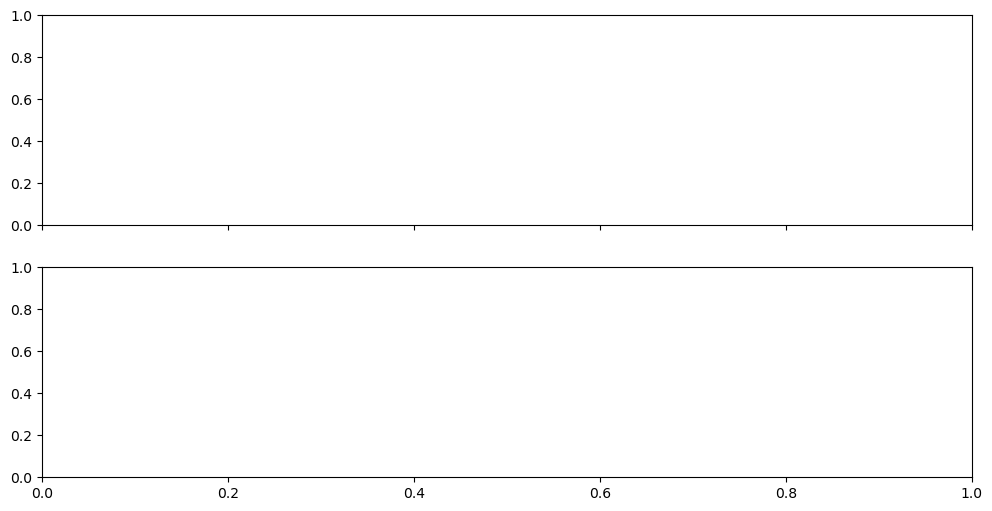

In [14]:
#init multi-analyzer
M = Multi_Experiment_Analyzer(jsons, fallback_jsons)

#Retrieve trajectories and loss data
M.retrieve_data()

#Generate plots of exps against latents
M.plot_diffs_against_latents()

#Plot Potentials of each latent against the input
M.plot_all_potentials()

#Plot RMSD and Potential comparisons of all models in the multianalyzer
M.plot_all_diffs()

#Save a BAT trajectory of all experiments loaded into the MultiAnalyzer
#Crambin ~700 atoms and 1600 frames for model outputs, conversion is about 2.5s per experiment
#M.save_all_as_BAT() #UNCOMMENT THIS LINE

In [16]:
# #Init an analyzer
A = Experiment_Analyzer('jsons/modelH/modelH_04_2.json')

# #Get the trajs
A.retrieve_enc_and_dec_trajs()

# #Get the loss vals over training from npys
A.retrieve_loss_from_npy()

# #Plot potential of input and output
A.plot_potentials()

# #Plot difference hist of rmsd and potential
A.plot_diffs()

# #Metrics of distributions from plot_diffs
rmsd_ave, rmsd_std, pot_ave, pot_std = A.obtain_pairwise_distribution_metrics()

# #PLot losses from training
A.plot_losses(show_scaling=True, save_me=False, show_me=True)

IndexError: list index out of range

In [11]:
#Correlation Analysis
R2_matrix = jnp.corrcoef(A.test_data.T)**2
coefs = jnp.logspace(-3,0, 100)[:-1]
max_pair = 1925*1926 #remove set of self correlated dimensions
corr_count = []

for coef in coefs:
    print(coef)
    rows, cols = jnp.where(R2_matrix > coef)
    corr_count.append(len(rows) - 1926)

corr_count = jnp.array(corr_count)

0.001
0.0010722671
0.0011497568
0.0012328464
0.0013219408
0.0014174737
0.0015199113
0.0016297508
0.0017475284
0.0018738183
0.002009233
0.0021544343
0.0023101305
0.0024770768
0.0026560882
0.0028480361
0.0030538554
0.003274549
0.0035111913
0.003764935
0.0040370165
0.004328762
0.0046415874
0.004977024
0.005336699
0.0057223644
0.00613591
0.006579331
0.0070548006
0.0075646355
0.008111309
0.008697491
0.009326033
0.0100000035
0.010722671
0.011497568
0.012328467
0.013219408
0.0141747445
0.015199108
0.01629751
0.017475285
0.018738173
0.020092333
0.021544343
0.023101304
0.024770763
0.026560882
0.02848036
0.030538548
0.032745488
0.035111915
0.037649352
0.040370174
0.043287624
0.046415895
0.049770225
0.053366993
0.057223674
0.06135907
0.06579333
0.07054804
0.07564631
0.08111308
0.08697491
0.09326034
0.10000001
0.1072267
0.114975676
0.12328467
0.13219412
0.14174742
0.15199114
0.16297506
0.17475282
0.18738173
0.20092331
0.21544349
0.231013
0.24770758
0.26560876
0.28480357
0.30538556
0.32745495
0.351

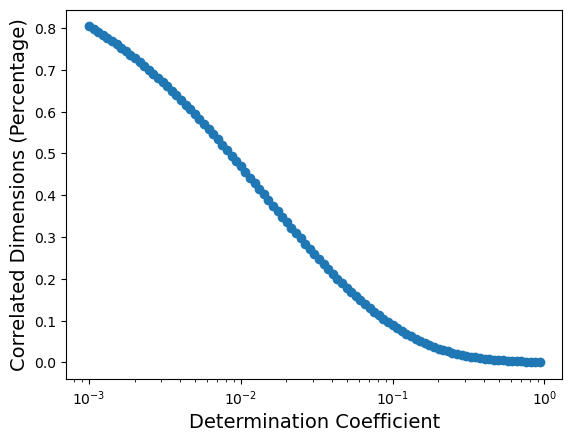

In [12]:
plt.clf()
_ = plt.scatter(coefs, corr_count/max_pair)
plt.xscale('log')
plt.ylabel('Correlated Dimensions (Percentage)', fontsize=14)
plt.xlabel("Determination Coefficient", fontsize=14)
plt.show()

In [13]:
sim_BAT = jnp.array(np.load('BAT_coords/1crn_H_100ns_BAT.npy'))

In [14]:
#Correlation Analysis
R2_matrix = jnp.corrcoef(sim_BAT.T)**2
coefs = jnp.logspace(-3,0, 100)[:-1]
max_pair = 1925*1926 #remove set of self correlated dimensions
corr_count = []

for coef in coefs:
    print(coef)
    rows, cols = jnp.where(R2_matrix > coef)
    corr_count.append(len(rows) - 1926) #1926 dimensions

corr_count = jnp.array(corr_count)

0.001
0.0010722671
0.0011497568
0.0012328464
0.0013219408
0.0014174737
0.0015199113
0.0016297508
0.0017475284
0.0018738183
0.002009233
0.0021544343
0.0023101305
0.0024770768
0.0026560882
0.0028480361
0.0030538554
0.003274549
0.0035111913
0.003764935
0.0040370165
0.004328762
0.0046415874
0.004977024
0.005336699
0.0057223644
0.00613591
0.006579331
0.0070548006
0.0075646355
0.008111309
0.008697491
0.009326033
0.0100000035
0.010722671
0.011497568
0.012328467
0.013219408
0.0141747445
0.015199108
0.01629751
0.017475285
0.018738173
0.020092333
0.021544343
0.023101304
0.024770763
0.026560882
0.02848036
0.030538548
0.032745488
0.035111915
0.037649352
0.040370174
0.043287624
0.046415895
0.049770225
0.053366993
0.057223674
0.06135907
0.06579333
0.07054804
0.07564631
0.08111308
0.08697491
0.09326034
0.10000001
0.1072267
0.114975676
0.12328467
0.13219412
0.14174742
0.15199114
0.16297506
0.17475282
0.18738173
0.20092331
0.21544349
0.231013
0.24770758
0.26560876
0.28480357
0.30538556
0.32745495
0.351

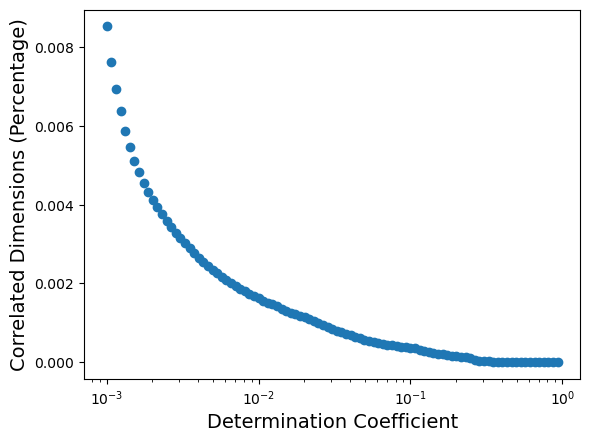

In [15]:
plt.clf()
_ = plt.scatter(coefs, corr_count/max_pair)
plt.xscale('log')
plt.ylabel('Correlated Dimensions (Percentage)', fontsize=14)
plt.xlabel("Determination Coefficient", fontsize=14)
plt.show()